In [1]:
import pandas as pd

# Зчитування даних
df = pd.read_csv("_ab_test_data.csv")

# Кількість користувачів у групах
group_counts = df['test_group'].value_counts()

# Кількість конверсій у групах
conversions = df.groupby('test_group')['conversion'].sum()

# Рівень конверсії у групах
conversion_rate = df.groupby('test_group')['conversion'].mean()

# Дати початку та кінця тесту
start_date = pd.to_datetime(df['timestamp']).min()
end_date = pd.to_datetime(df['timestamp']).max()
duration_days = (end_date - start_date).days + 1

print("Кількість користувачів:", group_counts)
print("Кількість конверсій:", conversions)
print("Рівень конверсії:", conversion_rate)
print("Початок:", start_date, "Кінець:", end_date, "Тривалість:", duration_days, "днів")

Кількість користувачів: test_group
a    10013
b     9985
Name: count, dtype: int64
Кількість конверсій: test_group
a    611
b    889
Name: conversion, dtype: int64
Рівень конверсії: test_group
a    0.061021
b    0.089034
Name: conversion, dtype: float64
Початок: 2023-07-03 01:42:34.033708 Кінець: 2023-07-25 01:41:19.152664 Тривалість: 22 днів


In [2]:
from statsmodels.stats.proportion import proportions_ztest

# Кількість успішних конверсій у кожній групі
successes = df.groupby('test_group')['conversion'].sum().values

# Кількість користувачів у кожній групі
nobs = df['test_group'].value_counts().values

# Z‑тест для двох пропорцій
z_stat, p_val = proportions_ztest(successes, nobs)

print("Z-statistic:", z_stat)
print("p-value:", p_val)

Z-statistic: -7.519675939906207
p-value: 5.491217728445103e-14


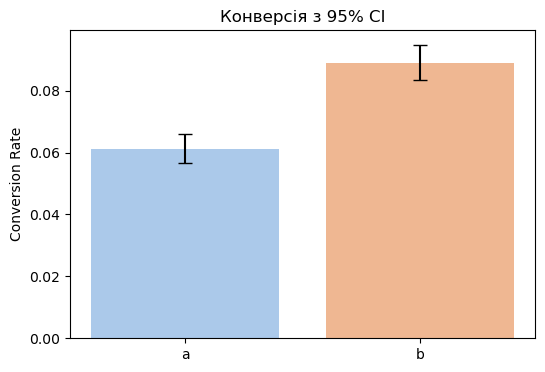

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.api as sms

# Кількість успішних конверсій у кожній групі
successes = df.groupby('test_group')['conversion'].sum().values
# Кількість користувачів у кожній групі
nobs = df['test_group'].value_counts().values
# Рівень конверсії у групах
conversion_rate = df.groupby('test_group')['conversion'].mean()

# Розрахунок довірчих інтервалів для кожної групи
ci_A = sms.proportion_confint(successes[0], nobs[0], alpha=0.05, method='wilson')
ci_B = sms.proportion_confint(successes[1], nobs[1], alpha=0.05, method='wilson')

rates = conversion_rate.values
groups = conversion_rate.index.tolist()   # ['a','b'] замість ['A','B']
cis = [ci_A, ci_B]

plt.figure(figsize=(6,4))
sns.barplot(x=groups, y=rates, hue=groups, palette="pastel")

# Додаємо довірчі інтервали
for i, ci in enumerate(cis):
    plt.errorbar(i, rates[i],
                 yerr=[[rates[i]-ci[0]], [ci[1]-rates[i]]],
                 fmt='none', c='black', capsize=5)

plt.title("Конверсія з 95% CI")
plt.ylabel("Conversion Rate")
plt.show()

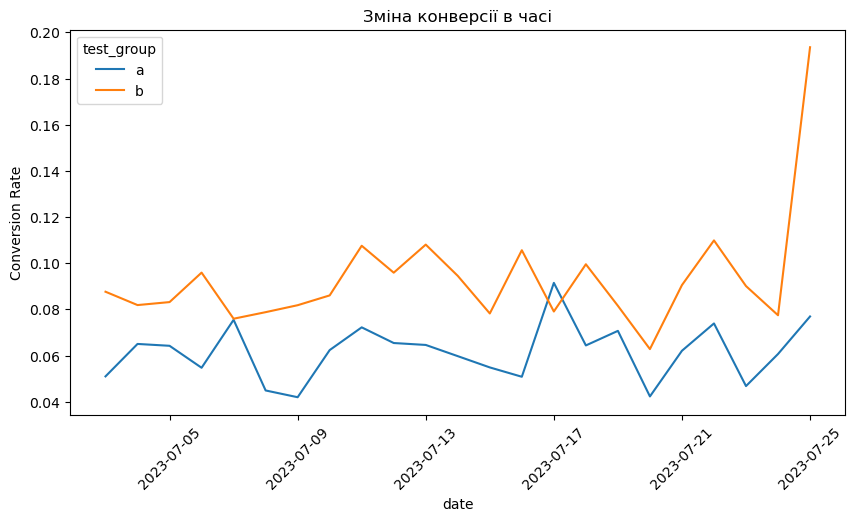

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Перетворюємо timestamp у дату (без часу)
df['date'] = pd.to_datetime(df['timestamp']).dt.date

# Групуємо за датою та групою
daily_conv = df.groupby(['date','test_group'])['conversion'].mean().reset_index()

# Побудова графіка
plt.figure(figsize=(10,5))
sns.lineplot(data=daily_conv, x='date', y='conversion', hue='test_group')
plt.title("Зміна конверсії в часі")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.show()